<a href="https://colab.research.google.com/github/MaryamAmjad2/PyTorch/blob/main/01_PyTorch_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import numpy as np
from torch import nn
import matplotlib.pyplot as plt

In [ ]:
torch.__version__

'2.11.0+cpu'

# Data Preparation and Loading

In [ ]:
  ## Creating Known Parameters for learning

weight=0.7
bias=0.3

#Create

start=0
end=1
step=0.02
X=torch.arange(start,end,step).unsqueeze(dim=1)
y=weight*X + bias

X[:10],y[:10]

# print(X)
# print(X.shape)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
len(X), len(y)

(50, 50)

# 2. Split Data




## Simple Method Just for learning

In [ ]:
train_split=int(0.8 *len(X))

X_train,y_train=X[:train_split],y[:train_split]
X_test,y_test=X[train_split: ],y[train_split: ]



NameError: name 'X' is not defined

In [ ]:
len(X_train),len(X_test)

(40, 10)

# 3. Building Function to Visualize

In [ ]:
def plot_prediction(X_train=X_train,X_test=X_test,y_train=y_train,y_test=y_test,prediction=None):
  """"""
  plt.figure(figsize=(10,7))

  ##Plot Training Data
  plt.scatter(X_train,y_train.detach().numpy(),c="b",s=10,label="Training Data")


  ##Plot Test Data
  plt.scatter(X_test,y_test.detach().numpy(),c='orange',label="Testing Data")


  ## Are there pred?
  if  prediction is not None:
    #  PLot prediction
    plt.scatter(X_test,prediction.detach().numpy(),c='red',label="predictions")
  plt.legend(prop={"size":14})

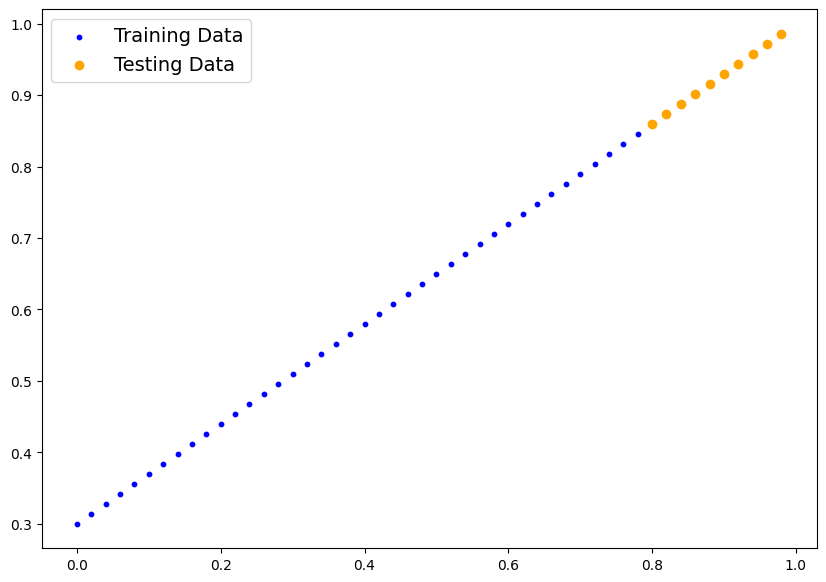

In [ ]:
plot_prediction()

# 4. Build a Model

In [ ]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights=nn.Parameter(torch.randn(1,   ## nn.parameter tell torch its a trainable and keep track of it
                                          requires_grad=True,
                                          dtype=torch.float32))
    self.bias=nn.Parameter(torch.randn(1,
                                       requires_grad=True,
                                       dtype=torch.float32
                                      ))


    #Forward Method to def the computaion

  def forward(self,x:torch.Tensor)->torch.Tensor:
    return self.weights*x+self.bias




## PyTorch Model Building Essentials


*   torch.nn
*   torch.nn.parameter
*   torch.nn.Module
* torch.optim  
*   torch.loss
*   def forward()










## Checking the content of our Model

In [ ]:
torch.manual_seed(42)

model_0=LinearRegressionModel()


# Check out Parameters

list(model_0.parameters())


## Listed named parameters
model_0.state_dict()


OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
torch.randn(2)

tensor([0.2345, 0.2303])

# Making Predictions Using Inference Mode

In [ ]:
with torch.inference_mode():
  y_pred=model_0(X_test)
  print(y_pred)

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


In [ ]:
print(y_test)

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])


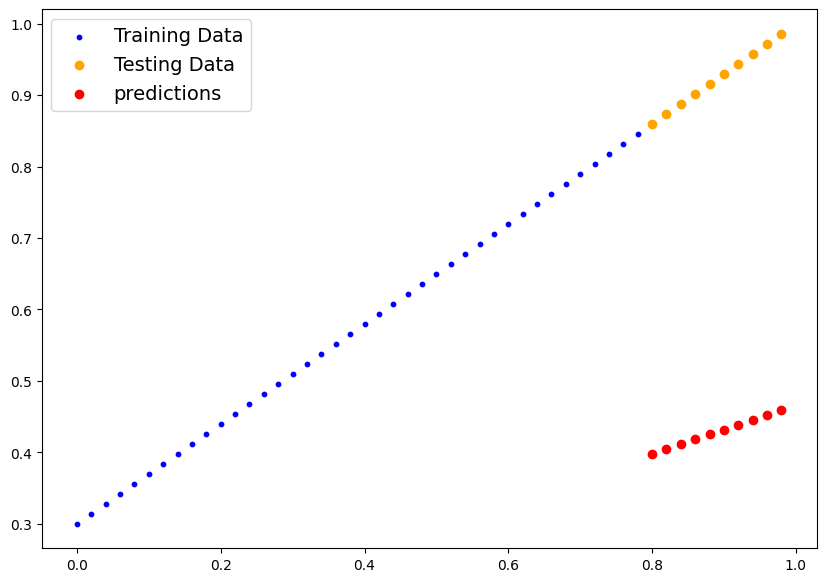

In [ ]:
plot_prediction(prediction=y_pred)

 # Training Model

In [ ]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

## Loss Function

In [ ]:
loss_fn=nn.L1Loss()  # Mean Abs Error

## Optimizer

In [ ]:
optimmizer=torch.optim.SGD(model_0.parameters(),lr=0.01)

## Buiding the training loop

In [ ]:
torch.manual_seed(42)

epochs=200

#Tracking Model loss
epoch_count=[]
loss_value=[]
test_loss_value=[]

for epoch in range(epochs):

  # 1 Set the model to train mode
  model_0.train() #Sets all parameters that require grad

  # 2 Forwardd Pass
  y_pred=model_0(X_train)

  # 3 Calculate loss

  loss=loss_fn(y_pred,y_train)
  loss_value.append(loss.item())

  # 4 Optimizer
  optimmizer.zero_grad()

  # 5 Back propaagtaion
  loss.backward()

  # 6 Step the optimizeer
  optimmizer.step()


  ## Testing
  model_0.eval() #turn of diff setting in the model not neeeded for eval
  with torch.inference_mode():
    test_pred=model_0(X_test)
    test_loss=loss_fn(test_pred,y_test)
    test_loss_value.append(test_loss.item())


  epoch_count.append(epoch)

  # Print out what's happening every 10 epochs
  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | L1 Loss: {loss:.4f} | Test L1 Loss: {test_loss:.4f}")

Epoch: 0 | L1 Loss: 0.3129 | Test L1 Loss: 0.4811
Epoch: 10 | L1 Loss: 0.1977 | Test L1 Loss: 0.3464
Epoch: 20 | L1 Loss: 0.0891 | Test L1 Loss: 0.2173
Epoch: 30 | L1 Loss: 0.0531 | Test L1 Loss: 0.1446
Epoch: 40 | L1 Loss: 0.0454 | Test L1 Loss: 0.1136
Epoch: 50 | L1 Loss: 0.0417 | Test L1 Loss: 0.0992
Epoch: 60 | L1 Loss: 0.0382 | Test L1 Loss: 0.0889
Epoch: 70 | L1 Loss: 0.0348 | Test L1 Loss: 0.0806
Epoch: 80 | L1 Loss: 0.0313 | Test L1 Loss: 0.0723
Epoch: 90 | L1 Loss: 0.0279 | Test L1 Loss: 0.0647
Epoch: 100 | L1 Loss: 0.0245 | Test L1 Loss: 0.0565
Epoch: 110 | L1 Loss: 0.0210 | Test L1 Loss: 0.0482
Epoch: 120 | L1 Loss: 0.0176 | Test L1 Loss: 0.0406
Epoch: 130 | L1 Loss: 0.0142 | Test L1 Loss: 0.0323
Epoch: 140 | L1 Loss: 0.0107 | Test L1 Loss: 0.0241
Epoch: 150 | L1 Loss: 0.0073 | Test L1 Loss: 0.0165
Epoch: 160 | L1 Loss: 0.0039 | Test L1 Loss: 0.0082
Epoch: 170 | L1 Loss: 0.0089 | Test L1 Loss: 0.0050
Epoch: 180 | L1 Loss: 0.0089 | Test L1 Loss: 0.0050
Epoch: 190 | L1 Loss: 0

In [ ]:
with torch.inference_mode():
  y_pred_new=model_0(X_test)


In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

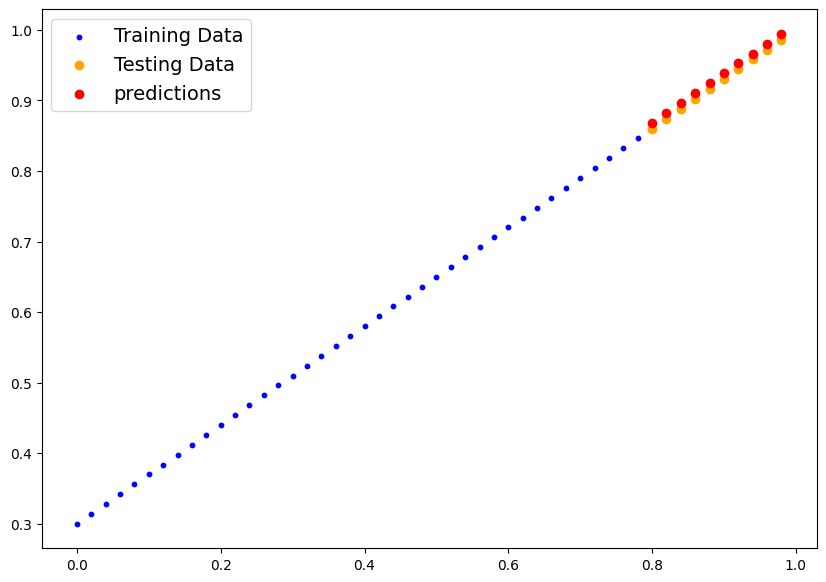

In [ ]:
plot_prediction(prediction=y_pred_new)

# Testing Code

In [ ]:
# model_0.eval() #turn of diff setting in the model not neeeded for eval
# with torch.inference_mode():
#   test_pred=model_0(X_test)
#   test_loss=loss_fn(test_pred,y_test)
# print(f' Test Loss is {test_loss}')


# used it in the  same cell as training


# Plot the loss Curve

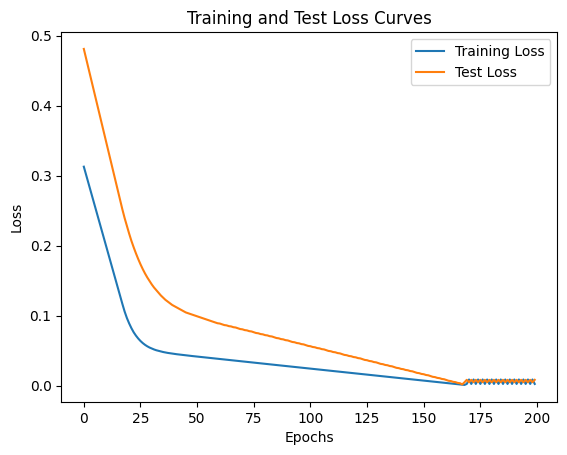

In [ ]:
plt.plot(epoch_count,loss_value,label="Training Loss")
plt.plot(epoch_count,test_loss_value,label="Test Loss")
plt.title("Training and Test Loss Curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

# Save Model

Three main ways to Save and Load Models
1. torch.save()
2. torch.load()
3. torch.nn.Module.load_state_dict


In [ ]:
from pathlib import Path

# Creare model directory
MODEL_PATH=Path(" MY model")
MODEL_PATH.mkdir(parents=True,exist_ok=True)

# Model Save
MODEL_NAME='1_Model.pth'
MODEL_SAVE_PATH=MODEL_PATH/MODEL_NAME

torch.save(model_0.state_dict(),MODEL_SAVE_PATH)
print("Model Saved")

Model Saved


## Load Model

In [ ]:
loaded_model=LinearRegressionModel()
loaded_model.load_state_dict(torch.load(MODEL_SAVE_PATH))

loaded_model.state_dict()

loaded_model.eval()

LinearRegressionModel()

In [ ]:
load_2=torch.load(MODEL_SAVE_PATH)
load_2  #This just gives you back a dictionary of {layer_name: tensor} sitting in load_2. It is not a model — you can't
#call load_2(X_test) to get predictions

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
with torch.inference_mode():
  loaded_model_preds=loaded_model(X_test)


In [ ]:
y_pred_new==loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])